### Matthew Shumaker
CDT 30020

Midterm Project: Exploratory Data Analysis

### Dataset Overview
1. Where did you find the dataset, and what is it about?
- I found the dataset in the TidyTuesday GitHub repo, under 2021. The dataset organizes nearly 1800 movies from 1970 – 2013 by whether or not they pass the "Bechdel Test" and to what degree is does/does not pass. A film passes the "Bechdel Test" if it has two women characters who talk to each other about something other than a man.
2. How many rows and columns does it have?
- The dataset has 1794 rows and 34 columns.
3. What is your guiding research question for the EDA?
- My guiding research question is to analyze certain genres and time periods to see if they produced films that pass the Bechdel Test, to think about why/why not, and to potentially analyze other categories to see if other correlations arise there as well, such as budget, runtime, awards won, etc.

## Exploratory Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2021/2021-03-09/movies.csv')

display(df.head(3))
print(f"Shape\n{df.shape}") # Very large dataset with many points
print(f"\nDtypes\n{df.dtypes}") # All datatypes look normal/expected. Mostly strings, integers, and floats
print(f"\nSummary\n{df.describe()}") # A wide variety of statistics, nothing looks out of the ordinary yet but something will arise soon I'm sure. High std dev in budgets, which makes sense given the variety of films (indie to blockbuster) and range of years.
print(f"\nYear Value Counts\n{df['year'].value_counts()}") # More recent movies, which is to be expected.
print(f"\nGenre Value Counts\n{df['genre'].value_counts()}") # Multiple genres in one. May see if I can narrow down to just first or second genre(s) listed.
print(f"\nType Value Counts\n{df['type'].value_counts()}") # What is type? Movie or null? What is null? Probably will drop for readability.
print(f"\nShow only 'type' null\n{df[df['type'].isnull()].head(5)}") # These are still movies..? Probably will drop the column unless I see something different.
print(f"\nShow only 'error' null\n{df[df['error'].isnull()].head(5)}") # Not certain what this is. Description on GitHub doesn't help either: "Error?". Probably will just drop the column.
print(f"\nChecking for missing values\n{df.isnull().sum()}") # Lots of missing values in various locations, but there are ~200 missing values for most of the string values towards the end, which may or may not be an issue.
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}") # No duplicate values

,year,imdb,title,test,clean_test,binary,budget,domgross,intgross,code,...,director,released,actors,genre,awards,runtime,type,poster,imdb_votes,error
0,2013,tt1711425,21 &amp; Over,notalk,notalk,FAIL,13000000,25682380.0,42195766.0,2013FAIL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012,tt1343727,Dredd 3D,ok-disagree,ok,PASS,45000000,13414714.0,40868994.0,2012PASS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013,tt2024544,12 Years a Slave,notalk-disagree,notalk,FAIL,20000000,53107035.0,158607035.0,2013FAIL,...,Steve McQueen,08 Nov 2013,"Chiwetel Ejiofor, Dwight Henry, Dickie Gravois...","Biography, Drama, History",Won 3 Oscars. Another 131 wins & 137 nominations.,134 min,movie,http://ia.media-imdb.com/images/M/MV5BMjExMTEz...,"143,446",NaN


Shape
(1794, 34)

Dtypes
year               int64
imdb              object
title             object
test              object
clean_test        object
binary            object
budget             int64
domgross         float64
intgross         float64
code              object
budget_2013        int64
domgross_2013    float64
intgross_2013    float64
period_code      float64
decade_code      float64
imdb_id            int64
plot              object
rated             object
response          object
language          object
country           object
writer            object
metascore        float64
imdb_rating      float64
director          object
released          object
actors            object
genre             object
awards            object
runtime           object
type              object
poster            object
imdb_votes        object
error            float64
dtype: object

Summary
              year        budget      domgross      intgross   budget_2013  \
count  1794.000000  1.79

General Observations:

Very large dataset with many points. All datatypes look normal/expected. Mostly strings, integers, and floats. A wide variety of statistics, nothing looks out of the ordinary yet but something will arise soon I'm sure. High std dev in budgets, which makes sense given the variety of films (indie to blockbuster) and range of years. Consists of more recent movies, which is to be expected. Many rows list multiple genres in one cell. May see if I can narrow down to just first or second genre(s) listed. What is `type`? The only options are `movie` or `null`? I assume null is some other type of media: TV Show or TV Movie, but hard to tell. Probably will drop the `type` column for readability. These are still movies..? Probably will drop the column unless I see something different. Not certain what the `error` column is. Description on GitHub doesn't help either: "Error?". Probably will just drop the column. Lots of missing values in various locations, but there are ~200 missing values for most of the string values towards the end, which may or may not be an issue. There are no duplicate values.

In [2]:
## Looking into different possibilities for passing test (test, clean_test, binary)
## There is no info on what each different value means on the GitHub Page, so this is just my best assumption

print(f"{df['test'].value_counts()}\n")
print(f"{df['clean_test'].value_counts()}\n")
print(df['binary'].value_counts())

test
ok                  696
notalk              379
notalk-disagree     135
men                 125
ok-disagree         107
nowomen              88
dubious              81
men-disagree         69
dubious-disagree     61
nowomen-disagree     53
Name: count, dtype: int64

clean_test
ok         803
notalk     514
men        194
dubious    142
nowomen    141
Name: count, dtype: int64

binary
FAIL    991
PASS    803
Name: count, dtype: int64


## Correlations & Group Comparisons

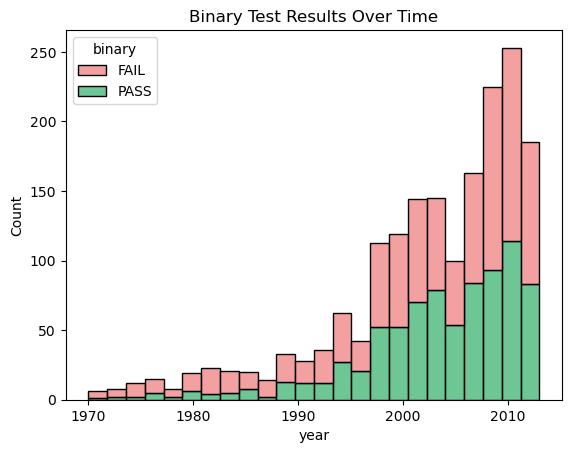

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df.drop(columns=['imdb','type','poster', 'error', 'period_code', 'decade_code', 'imdb_id', 'plot', 'writer', 'actors', 'imdb_votes']) # Dropping columns that will not be used for clarity (either long strings, or values that won't be relevant for this analysis.)
df_clean = df.drop(columns=['budget','domgross','intgross']) # Dropping these columns to favor budget_2013, domgross_2013, and intgross_2013, which are normalised to 2013 dollars.

sns.histplot(
    df_clean,
    x='year',
    hue='binary',
    multiple='stack', 
    palette={'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'}
    )

plt.title("Binary Test Results Over Time")
plt.show()

# Want to look at genre next but need to clean that up.

On a quick glance, looks generally 50/50. Going to look deeper.

In [4]:
# Looking at Genre now. Some films have multiple genres, so I'm going to split each genre and only use the first genre for better visualizations.
print(df['genre'].isnull().value_counts()) # 202 are null… ~11% of dataset.
display(df[df['genre'].isnull()].head(4)) # These look like a wide variety of different genres. It appears to be at random... maybe imdb has no genre listed? Probably will just drop. (I looked at more than just 5, but keeping this displayed for example purposes.)

df_dropgenrenull = df_clean[df['genre'].isnull()==False] ## Drop genres that are null
df_clean = df_dropgenrenull.reset_index(drop=True) ## Reset index

count = 0
for i in df_clean['genre']:
   df_clean.loc[count, 'genre'] = i.split(', ')[0]
   count += 1

df_clean.head(3)

genre
False    1592
True      202
Name: count, dtype: int64


,year,imdb,title,test,clean_test,binary,budget,domgross,intgross,code,...,director,released,actors,genre,awards,runtime,type,poster,imdb_votes,error
0,2013,tt1711425,21 &amp; Over,notalk,notalk,FAIL,13000000,25682380.0,42195766.0,2013FAIL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012,tt1343727,Dredd 3D,ok-disagree,ok,PASS,45000000,13414714.0,40868994.0,2012PASS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2013,tt1731141,Ender&#39;s Game,men,men,FAIL,110000000,61737191.0,89737191.0,2013FAIL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,2013,tt1905041,Fast and Furious 6,ok-disagree,ok,PASS,160000000,238679850.0,788128122.0,2013PASS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,year,imdb,title,test,clean_test,binary,code,budget_2013,domgross_2013,intgross_2013,...,director,released,actors,genre,awards,runtime,type,poster,imdb_votes,error
0,2013,tt2024544,12 Years a Slave,notalk-disagree,notalk,FAIL,2013FAIL,20000000,53107035.0,158607035.0,...,Steve McQueen,08 Nov 2013,"Chiwetel Ejiofor, Dwight Henry, Dickie Gravois...",Biography,Won 3 Oscars. Another 131 wins & 137 nominations.,134 min,movie,http://ia.media-imdb.com/images/M/MV5BMjExMTEz...,"143,446",NaN
1,2013,tt1272878,2 Guns,notalk,notalk,FAIL,2013FAIL,61000000,75612460.0,132493015.0,...,Baltasar Kormákur,02 Aug 2013,"Denzel Washington, Mark Wahlberg, Paula Patton...",Action,1 win.,109 min,movie,http://ia.media-imdb.com/images/M/MV5BNTQ5MTgz...,"87,301",NaN
2,2013,tt0453562,42,men,men,FAIL,2013FAIL,40000000,95020213.0,95020213.0,...,Brian Helgeland,12 Apr 2013,"Chadwick Boseman, Harrison Ford, Nicole Behari...",Biography,3 wins & 13 nominations.,128 min,movie,http://ia.media-imdb.com/images/M/MV5BMTQwMDU4...,"43,608",NaN


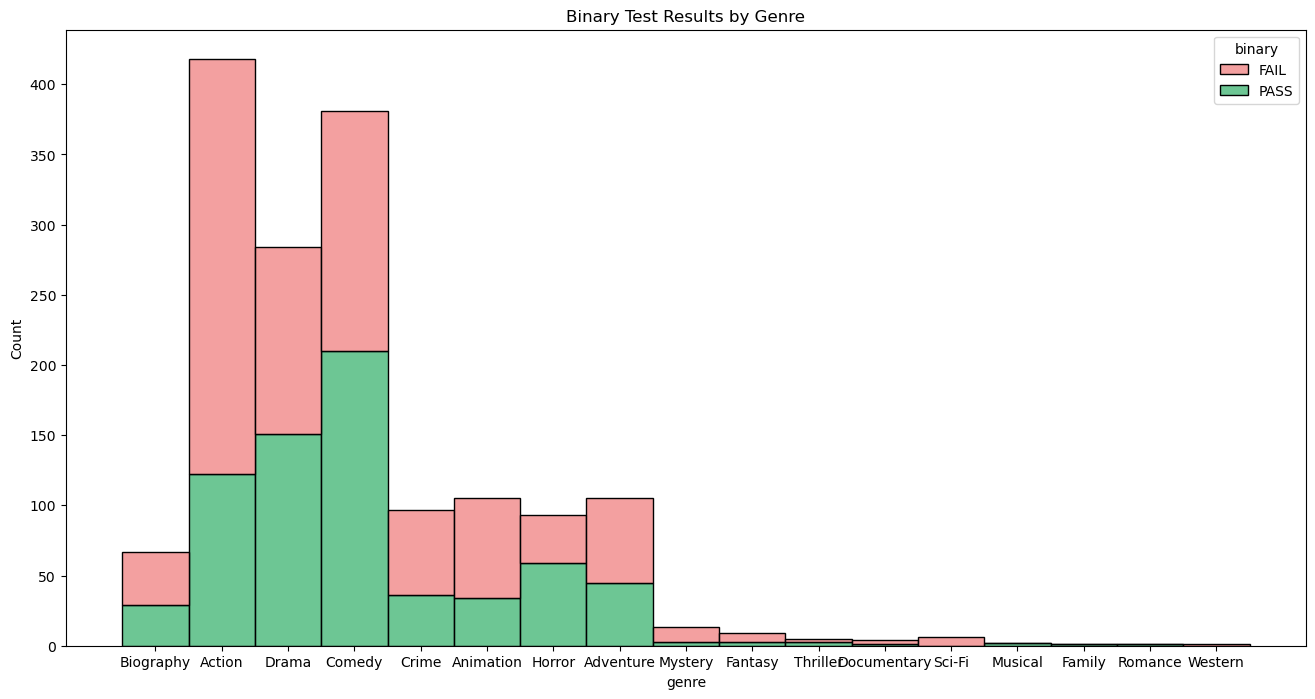

In [5]:
plt.figure(figsize=(16, 8)) # Have to make figure very large to read x-axis... maybe change font size?

sns.histplot(
    df_clean,
    x='genre',
    hue='binary',
    multiple="stack", 
    palette={'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'}
    )

plt.title('Binary Test Results by Genre')
plt.show()

Action being relatively low makes sense, same thing with comedies dramas being just over 50%. 
Most of these make sense, although I am surprised that horror has a majority pass rate, as I'd assume there's not much for two named women characters talk about other than a (traditonally) male antagonist.

,budget_2013,domgross_2013,intgross_2013,total_gross,binary_tf
budget_2013,1.000000,0.487193,0.610476,0.582097,-0.153736
domgross_2013,0.487193,1.000000,0.924876,0.962923,-0.108891
intgross_2013,0.610476,0.924876,1.000000,0.993172,-0.097659
total_gross,0.582097,0.962923,0.993172,1.000000,-0.102697
binary_tf,-0.153736,-0.108891,-0.097659,-0.102697,1.000000


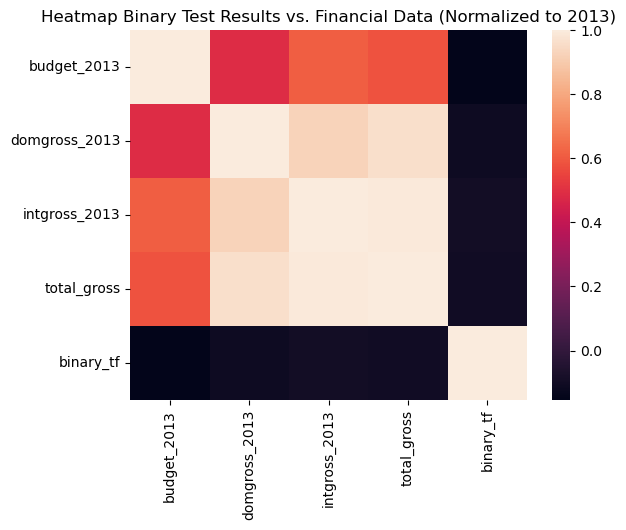

In [6]:
# Adding total gross column (domestic + international gross)
totalgross = [] # Creating empty list of total gross
for i in range(len(df_clean)): # Realizing now my method for slicing genre above was a little dumb (using a count variable) but it works. This is a bit better though
    totalgross.append(df_clean['domgross_2013'][i] + df_clean['intgross_2013'][i]) # Appending new total gross values to list
df_clean['total_gross'] = totalgross # Setting new total_gross column to list made in for loop

## Adding a row that sets pass/fail to true/false for correlation purposes
df_tf = [] # Doing the same thing as above, but this time making a list of booleans
for i in range(len(df_clean)):
     df_tf.append(df_clean['binary'][i] == 'PASS')
df_clean['binary_tf'] = df_tf

display(df_clean[['budget_2013', 'domgross_2013', 'intgross_2013','total_gross', 'binary_tf']].corr()) # I tried something, but it didn't work out as expected... maybe there is slight negative correlation?
sns.heatmap(df_clean[['budget_2013', 'domgross_2013', 'intgross_2013', 'total_gross', 'binary_tf']].corr()) # The heatmap is actually a little less clear. Not too many ranges of black.
plt.title("Heatmap Binary Test Results vs. Financial Data (Normalized to 2013)")
plt.show()

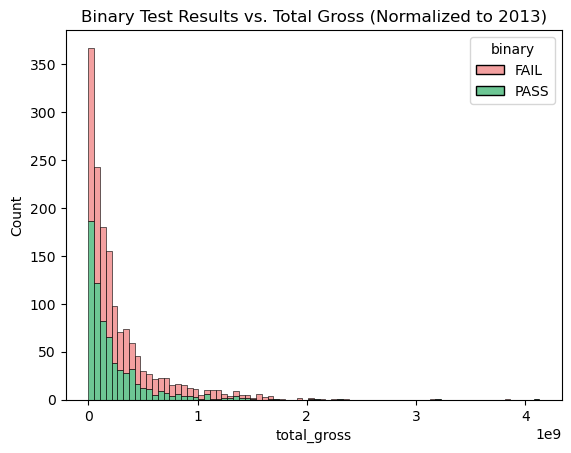

In [7]:
# Correlation between total gross and pass/fail. 
sns.histplot(df_clean,
             x = 'total_gross',
             hue = 'binary',
             multiple = "stack", 
            palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'})

plt.title('Binary Test Results vs. Total Gross (Normalized to 2013)')
plt.show()

It looks pretty 50/50 from afar, although moving more towards 1/4 pass as the gross increases.
Going to cut out the outliers to see better

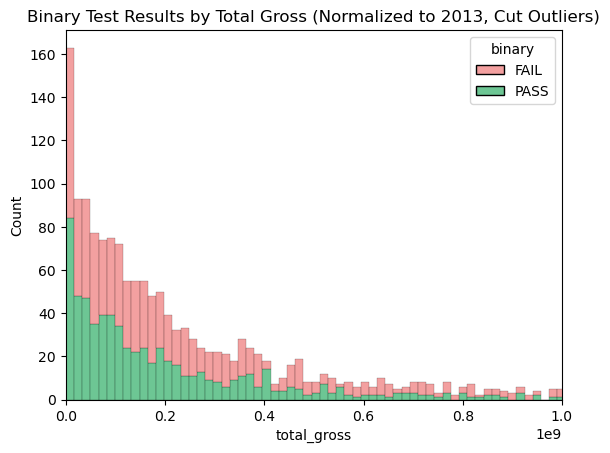

In [8]:
sns.histplot(df_clean,
             x = 'total_gross',
             hue = 'binary',
             multiple = "stack", 
            palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'},
            bins = 250) #increasing bins for better visibility as well

plt.xlim(0,1.0e+09) # Cutting outliers who grossed over $1bn to see better

plt.title('Binary Test Results by Total Gross (Normalized to 2013, Cut Outliers)')
plt.show()

Honestly, it looks pretty much 50/50. I'm surprised. There is a clear dropoff in passes past the $400mm (0.4) mark though.

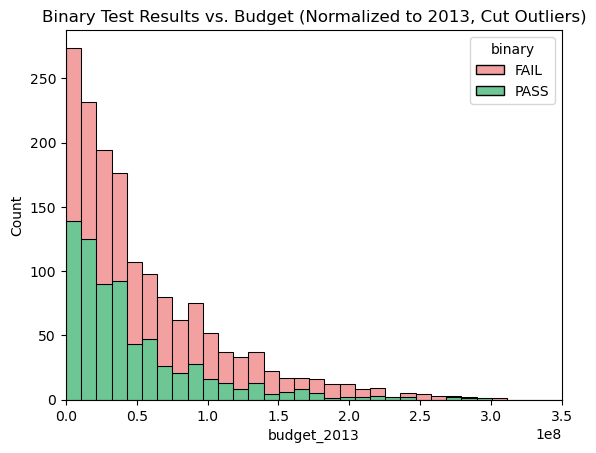

In [9]:
# Going to do the same with budget, which could be more telling (indie movies/lower budgets) have a higher pass rate?
sns.histplot(df_clean,
             x = 'budget_2013',
             hue = 'binary',
             multiple = "stack", 
            palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'})

plt.xlim(0,3.5e+08)
plt.title('Binary Test Results vs. Budget (Normalized to 2013, Cut Outliers)')
plt.show()

Looks pretty 50/50 until about 100mm.
I'm going to look even closer at indie movies, going to cut even 50mm

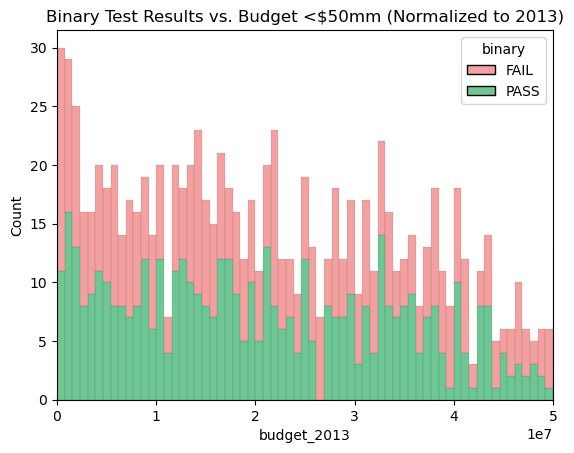

In [10]:
# Looking at indies (budget < 50mm, which is generous)
sns.histplot(df_clean,
             x = 'budget_2013',
             hue = 'binary',
             multiple = "stack", 
             palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'},
             bins = 600)

plt.xlim(0,5e+07)
plt.title('Binary Test Results vs. Budget <$50mm (Normalized to 2013)')
plt.show()

Also looks generally 50/50. Very interesting. Can't really see any kind of correlation here.

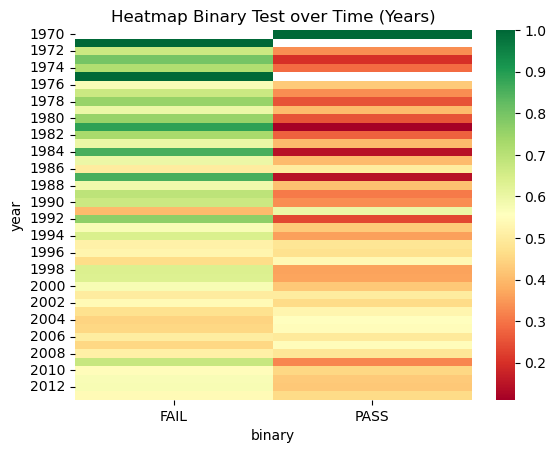

In [11]:
# Pass grouped by year %
year_binary = df_clean.groupby('year')['binary'].value_counts(normalize=True).unstack() # Percent pass by year.
sns.heatmap(year_binary,
            cmap = 'RdYlGn') # Deeper green has more of that value. So, mostly fails.
plt.title("Heatmap Binary Test over Time (Years)")
plt.show()
# The yellow makes this tough to read, but only a couple years with majority passes, this may look better in a line plot

Text(0.5, 1.0, 'Line Plot Binary Test Over Time (Years)')

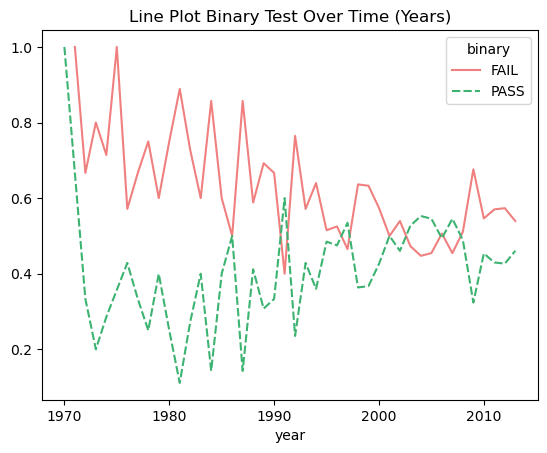

In [12]:
sns.lineplot(year_binary,
             palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'})
plt.title("Line Plot Binary Test Over Time (Years)")

Passing generally never beats failing... It breifly passed fail for a year in ~1991, the mid-90s, and a brief stint in the mid-2000's.

In [13]:
# In looking for language correlations, I fonud a silent movie with no language (as there is no dialogue). Dropping row.
display(df_clean[df_clean['language'].isnull()])
df_clean = df_clean.drop(index=1565).reset_index(drop=True)

,year,imdb,title,test,clean_test,binary,code,budget_2013,domgross_2013,intgross_2013,...,actors,genre,awards,runtime,type,poster,imdb_votes,error,total_gross,binary_tf
1565,1976,tt0075222,Silent Movie,notalk,notalk,FAIL,1976FAIL,18004040,147901939.0,147901939.0,...,"Mel Brooks, Marty Feldman, Dom DeLuise, Sid Ca...",Comedy,Nominated for 4 Golden Globes. Another 1 win &...,87 min,movie,http://ia.media-imdb.com/images/M/MV5BMTQzNDY4...,"9,951",NaN,295803878.0,False


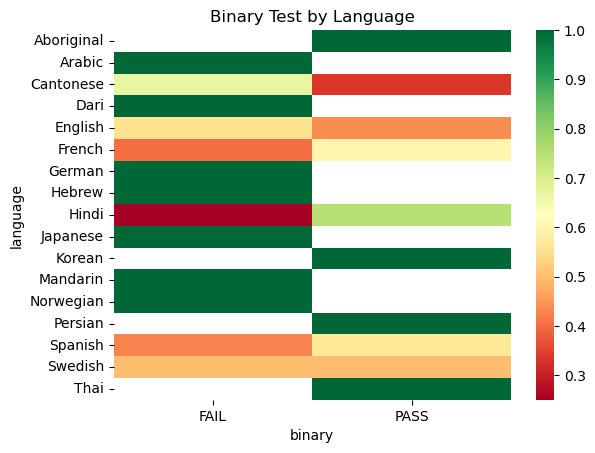

In [14]:
# Pass grouped by primary language.
# Only first (primary) language of film, for better data analysis.
# Using the same code as before because it worked
count = 0
for i in df_clean['language']:
   df_clean.loc[count, 'language'] = i.split(', ')[0]
   count += 1
    
pass_by_language = df_clean.groupby('language')['binary'].value_counts(normalize=True).unstack()
sns.heatmap(pass_by_language,
            cmap='RdYlGn')
plt.title("Binary Test by Language")
plt.show()

This may be due to a lack of data, but it seems that many foreign languages pass majority (French, Spanish) whereas English does not pass, but is close to 0.5

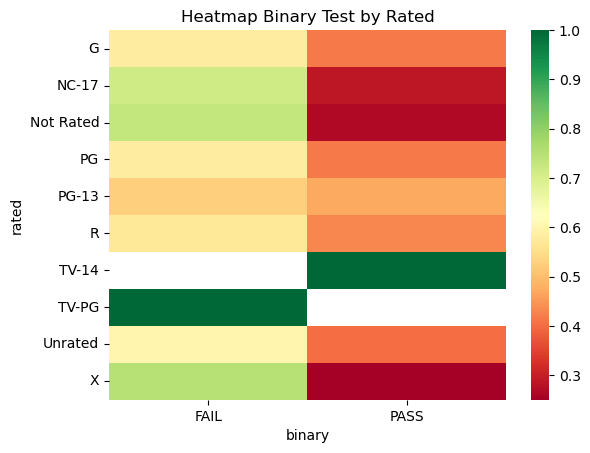

In [15]:
# Pass grouped by rating (PG-13, R, etc.)
pass_by_rated = df.groupby('rated')['binary'].value_counts(normalize=True).unstack()
sns.heatmap(pass_by_rated,
            cmap = 'RdYlGn')
plt.title("Heatmap Binary Test by Rated")
plt.show()

Only TV-14 (essentially PG-13 but for television) fully passed, with PG-13 being in the middle (but mostly failing). Otherwise mostly 60-40 on fail-pass. It looks like while most movies are generally hovering around 50/50 on passing or failing, they mostly lean towards the failing side, and there appears to be no overwhelming correlation between any of these categories (budget, film rated, years, etc).

## Advanced Visualizations

#### Violin Plot(s): Budget vs. Pass/Fall
I chose this chart to see a better/closer distinction in budgets, to see if there were an area I was overlooking budget-wise that could bring insights into why some films pass and others do not.

I included a total gross plot as well to see if I missed anything there as well.

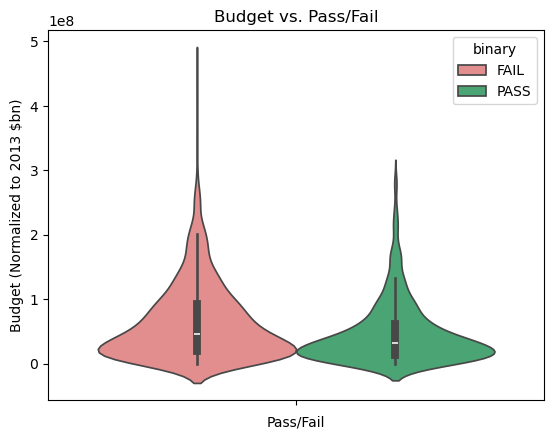

In [16]:
# Budget vs pass/fail
sns.violinplot(df_clean,
            hue = 'binary',
            y = 'budget_2013',
            palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'})

plt.title("Budget vs. Pass/Fail")
plt.xlabel("Pass/Fail")
plt.ylabel('Budget (Normalized to 2013 $bn)')
plt.show()

There does not appear to be much correlation. Most budgetts appear to be lower, but it still appears to be about equal with a leaning more towards failure.

I'm including total_gross here too, just in case something different shows up (it doesn't).

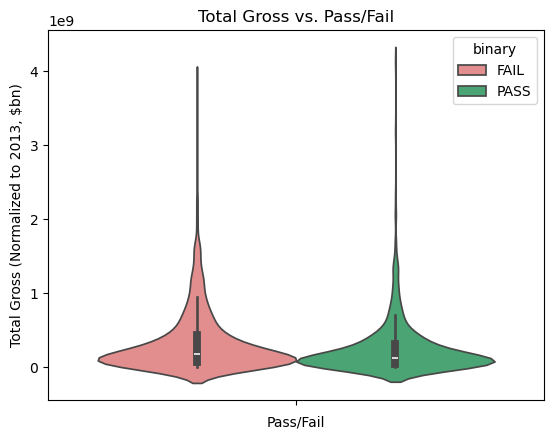

In [17]:
sns.violinplot(df_clean,
            hue = 'binary',
            y = 'total_gross',
            palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'})

plt.title("Total Gross vs. Pass/Fail")
plt.xlabel("Pass/Fail")
plt.ylabel('Total Gross (Normalized to 2013, $bn)')
plt.show()

Pretty much the same thing shows up. I'm surprised that total gross and budget aren't different. I went into this exercise assuming lower budget films would pass more, but throughout this whole process it has appeared that lower budget films (while being slightly closer to equal) are not substantially passing more than higher budget films. The spreads of both of these graphs are very similar as well.

#### Facet Grid: Film Rating Vs. Pass/Fail
I want to break down each rating (G, PG, PG-13, and R) into more detail, seeing if there was any change over time for each of these ratings.

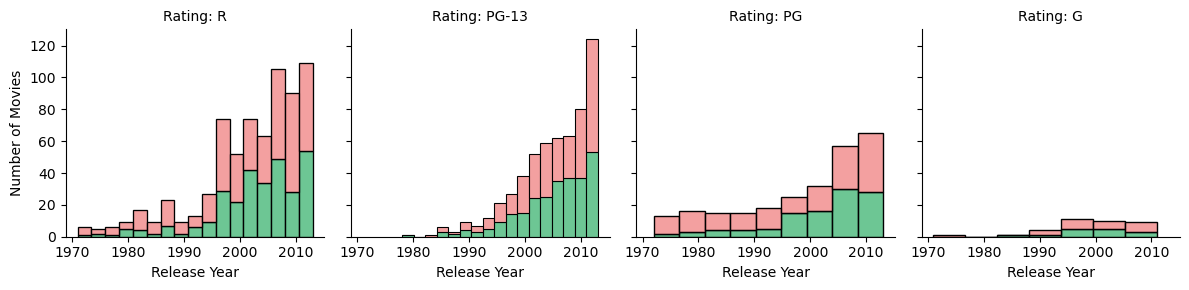

In [18]:
# Narrowing FacetGrid to exclusively the main MPAA ratings, as the others have <10 values that won't appear well on the visualization.
df_rated = df_clean[df_clean['rated'].isin(['G', 'PG', 'PG-13', 'R'])]

rated_grid = sns.FacetGrid(df_rated, col = "rated") # FacetGrid with multiple graphs being ratings

rated_grid.map_dataframe(sns.histplot, x = "year", hue = "binary", multiple = "stack", palette = {'PASS': 'mediumseagreen', 'FAIL': 'lightcoral'})

rated_grid.set_axis_labels("Release Year", "Number of Movies")
rated_grid.set_titles(template="Rating: {col_name}")
plt.show()

Once again, most movies appear to be relatively close in breakdown. In PG-13 through 2000–2010 passing appears to be the majority, but never appears to take the lead for all R-Rated movies. With PG films there has been a steady upward trend in passing throughout the years, but G-rated films are relatively uncommon (at least in this dataset) and tend to not pass the test.

#### KDE Plot: Pass/Fail over Time
I chose the KDE Plot to see density over time, to see distribution and relative frequency of the data points.

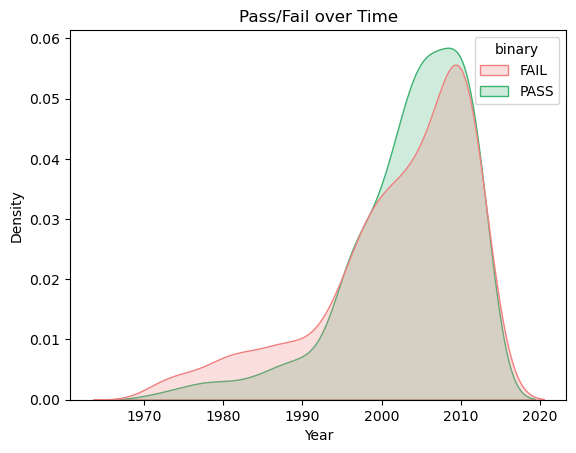

In [19]:
sns.kdeplot(
    df_clean, 
    x = 'year', 
    hue = 'binary', 
    fill = True, 
    common_norm=False,
    palette = {'PASS':'mediumseagreen','FAIL':'lightcoral'})

plt.xlabel('Year')
plt.title('Pass/Fail over Time')
plt.show()

This gave a great new perspective, allowing me to pinpoint the single small period of time in the early 2000s when passing became more frequent, which is a time period I want to look more into. By setting the common norm to false and making both lines' heights relatively equal, it became much easier to see this preiod of time, which I will look more into now.

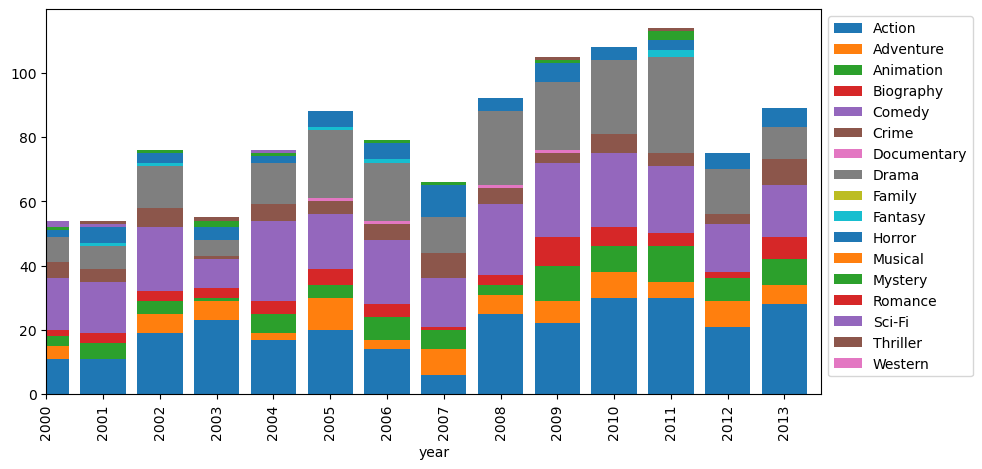

In [20]:
year_genre = df_clean.groupby(['year','genre']).size().unstack(fill_value=0) # Grouping by year and genre, setting null values to 0 for better graphing.

year_genre.plot(
    kind = 'bar',
    stacked = True,
    width = .8,
    figsize = (10,5))

plt.xlim(30)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

I see potentially an increase in comedy movies around this era,and a slight decrease in action movies (a very common category that fails the test.)

## Hypothesis Testing

#### Test 1

To settle my assumption that budget has an impact on passing the Bechdel Test. I am choosing the Two-Sample T-Test because it is the best to compare the mean (budget) across two groups (pass/fail).


H<sub>0</sub>: There is no difference in mean budget of films that pass vs. those that fail

H<sub>A</sub>: There is a difference in mean budget of films that pass vs. those that fail

α: 0.05

In [21]:
from scipy import stats

group_a = df_clean[df_clean["binary"] == "PASS"]["budget_2013"]
group_b = df_clean[df_clean["binary"] == "FAIL"]["budget_2013"]


t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.10f}") #changed to 10 decimals to find a digit.

t-statistic: -6.2205
p-value: 0.0000000006


Surprisingly against what I had assumed through the visualizations but in accordance to my assumptions, the p-value is below the alpha, meaning that this is statistically significant and the mean budget of films that pass the test do have a statistically significant difference from those that do not. 

The t-statistic is -6.2, meaning that the mean budget of films that pass the Bechdel Test are 6.2 standard errors below the mean budget of those that fail.

We reject the null hypothesis, now knowing that films that pass the Bechdel Test tend to have a much lower mean budget than those that do not.

The only potential caveat of this dataset is how high the budget of blockbusters may be compared to indie films, but that should not significantly change the data as those films appeared not to pass the test anyway.

#### Test 2

This is less related to the Bechdel Test, but still something that can be tested for with this dataset. I chose the Pearson Correlation Test because there appeared to be a correlation between budget and the multiple gross values in the heatmap above, and I wanted to test if that was true. Additionally, this test may help bring insights about other anomalies found in other visualizations.

H<sub>0</sub>: There is no relationship between budget and total gross (normalized to 2013).

H<sub>A</sub>: There is a statistically significant relationship between budget and total gross (normalized to 2013).

In [22]:
# Budget vs total gross
df_dropna = df_clean.dropna(subset=['budget_2013','total_gross']) # Dropping null values (test didn't run with null values included)

r, p_value = stats.pearsonr(df_dropna["budget_2013"], df_dropna["total_gross"])
print(f"Pearson r: {r:.4f}")
print(f"p-value: {p_value:.145f}") # Changed to 145 decimals to find a value. This is a very small number.

Pearson r: 0.5822
p-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000116


The Pearson r is above 0.5, which is relatively close, but not high enough to be evident of an incredibly strong relationship. Still, one will reject the null hypothesis as the p-value is very well below alpha.

This means that there is a statistically significant relationship between budget and total gross, meaning that a film's budget is a good indicator of its total gross.

A caveat here is the same as the one above: blockbusters. These films with incredibly high budgets are pretty safe bets, but can minimize the riskier films with lower budgets that are also represented in this dataset. 

Additionally, this helps to explain why the pass/fail rate for films between the budget and gross charts are similar, as they have a statistically significant relationship.

## Final EDA Summary

#### A. Summary of Major Findings

I was surprised by just how 50/50 most of this dataset appeared to be. Every type of visualization I attempted to see something new with, I was presented with a new angle to see a rougly 55/45 relationship between failing and passing that this dataset revealed. However, when I finally began hypothesis testing, I found that my initial assumption that movies that tended to pass the test had a lower budget was proven right. This was the finding that was most likely the strongest related to my guiding research question. Additionally, doing the hypothesis test of budget vs. total gross helped me to gain an even deeper insight into how these two are related (and the fact that they are, statistically speaking). This test allowed me to see how most of the relationships I attemped to visualize earlier were simply different ways of looking at the same things that were highly correlated and assume how the data may affect this.


#### B. Limitations and Caveats

The most significant limitation of this dataset are the extensive null values and the few extreme outliers ($bn higher than similar datapoints). As this dataset was compiled in 2021, I would've liked to see more recent data to see how this statistic has changed as the means of creating film has become exponentially easier and cheaper, which I assume will lead to films with better representation and thus pass the test more. A potential point of bias is the selection of movies, as it can be difficult to understand why some movies may have been selected over others, but provides a relatively comprehensive list of films released in its 43-year timespan. While there were many missing values (to be expected as reporting standards in the 80s were different than the 2010s) there seemed to be no major errors.


#### C. Next Steps

To continue this analysis, I would take a look at the more in-depth test results instead of the purely binary Pass/Fail column. Additionally I would look more into data that I spliced, like `genre` and `language` to find a more nuanced look at these categories. I would look at review scores as well. Introducing many more categories makes an exploratory data analysis of this size exponentially more difficult, however. I would probably want to collect some more numerical data, although this dataset had essentially everything needed already. I would say that this data is most likely suitable for building a predictive model to find if a film will pass the bechdel test or not without having watched the film/read the script.